# Лабораторная работа №1
## Анализ и прогнозирование временных рядов на примере розничных продаж.

Исходные данные: Времянной ряд из `retail_sales_mock_data.csv`, который содержит помесячные продажи и два флага, была ли акция и праздничный ли это месяц.



## 1. Загрузка и проверка данных
Проверим структуру таблицы, наличие пропусков, дубликатов и регулярность наблюдений.

In [1]:
import io
import pandas as pd
from google.colab import files

uploaded = files.upload()

# Используем имя выбранного файла, чтобы не зависеть от его переименования
file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

display(df.head())

Saving retail_sales_mock_data.csv to retail_sales_mock_data.csv


,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [2]:
print(f"Строк: {df.shape[0]}, столбцов: {df.shape[1]}")
df.info()

display(df.isna().sum().to_frame(name="Количество пропусков"))

print("Полных дубликатов:", df.duplicated().sum())
print("Повторяющихся дат:", df["Date"].duplicated().sum())

Строк: 48, столбцов: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          48 non-null     object
 1   SalesAmount   48 non-null     int64 
 2   Promotion     48 non-null     int64 
 3   HolidayMonth  48 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.6+ KB


,Количество пропусков
Date,0
SalesAmount,0
Promotion,0
HolidayMonth,0


Полных дубликатов: 0
Повторяющихся дат: 0


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

expected_dates = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="MS"
)

missing_dates = expected_dates.difference(df.index)
print("Пропущенных месяцев:", len(missing_dates))

# MS — месячная частота с датой в начале каждого месяца
df = df.asfreq("MS")

print(
    f"Период: {df.index.min():%Y-%m} — {df.index.max():%Y-%m}"
)
print("Частота:", df.index.freqstr)

display(df.head())

Пропущенных месяцев: 0
Период: 2020-01 — 2023-12
Частота: MS


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


Данные содержат 48 ежемесячных наблюдений за январь 2020 — декабрь 2023 года. Пропусков, дубликатов и отсутствующих месяцев в файле нет.

Целевой ряд — SalesAmount. Promotion и HolidayMonth являются дополнительными признаками, которые можно использовать в SARIMAX.

Даты преобразованы во временной индекс с месячной частотой MS.

## 2. Разведочный анализ данных

Последние 12 месяцев выделим в тестовую выборку. На обучающей части изучим динамику продаж, распределение значений, сезонность и связь с дополнительными признаками.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Сохраняем временной порядок наблюдений
train = df.iloc[:-12].copy()
test = df.iloc[-12:].copy()

y_train = train["SalesAmount"]
y_test = test["SalesAmount"]

print(
    f"Обучение: {train.index.min():%Y-%m} — "
    f"{train.index.max():%Y-%m}, {len(train)} месяцев"
)
print(
    f"Тест: {test.index.min():%Y-%m} — "
    f"{test.index.max():%Y-%m}, {len(test)} месяцев"
)

Обучение: 2020-01 — 2022-12, 36 месяцев
Тест: 2023-01 — 2023-12, 12 месяцев


In [5]:
display(y_train.describe().round(2).to_frame(name="SalesAmount"))

,SalesAmount
count,36.00
mean,11511.86
std,2233.19
min,7783.00
25%,9929.25
50%,11674.50
75%,12795.75
max,16623.00


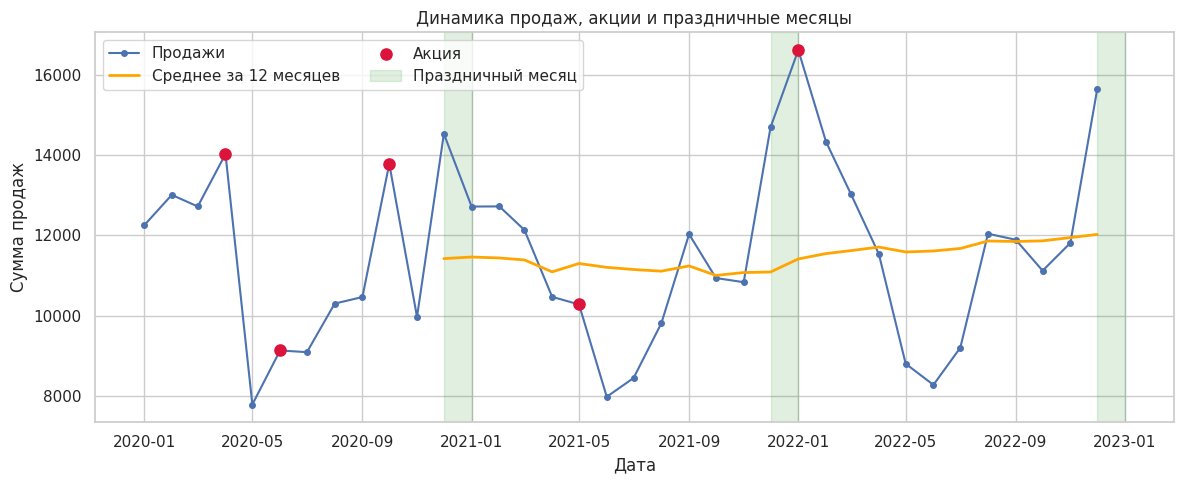

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    y_train.index, y_train,
    marker="o", markersize=4, label="Продажи"
)

ax.plot(
    y_train.index,
    y_train.rolling(12).mean(),
    color="orange",
    linewidth=2,
    label="Среднее за 12 месяцев"
)

# Отмечаем месяцы с акциями
promo_mask = train["Promotion"] == 1

ax.scatter(
    train.index[promo_mask],
    y_train.loc[promo_mask],
    color="crimson",
    s=65,
    zorder=4,
    label="Акция"
)

# Закрашиваем праздничный месяц целиком
holiday_dates = train.index[train["HolidayMonth"] == 1]

for i, date in enumerate(holiday_dates):
    ax.axvspan(
        date,
        date + pd.offsets.MonthBegin(1),
        color="green",
        alpha=0.12,
        label="Праздничный месяц" if i == 0 else None
    )

ax.set(
    title="Динамика продаж, акции и праздничные месяцы",
    xlabel="Дата",
    ylabel="Сумма продаж"
)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()

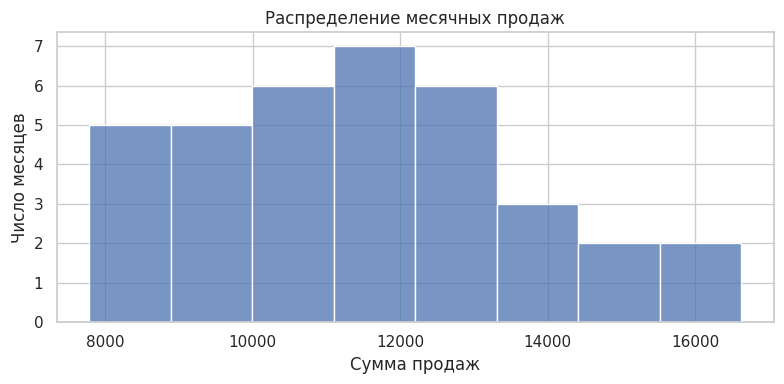

In [9]:
'''
Это гистограмма распределения продаж: она показывает, сколько месяцев имели продажи в определённом диапазоне.
Например, в наших обучающих данных 7 месяцев имеют продажи примерно от 11 100 до 12 200.
Поэтому соответствующий столбец имеет высоту 7.
'''
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(x=y_train, bins=8, ax=ax)

ax.set(
    title="Распределение месячных продаж",
    xlabel="Сумма продаж",
    ylabel="Число месяцев"
)

plt.tight_layout()
plt.show()

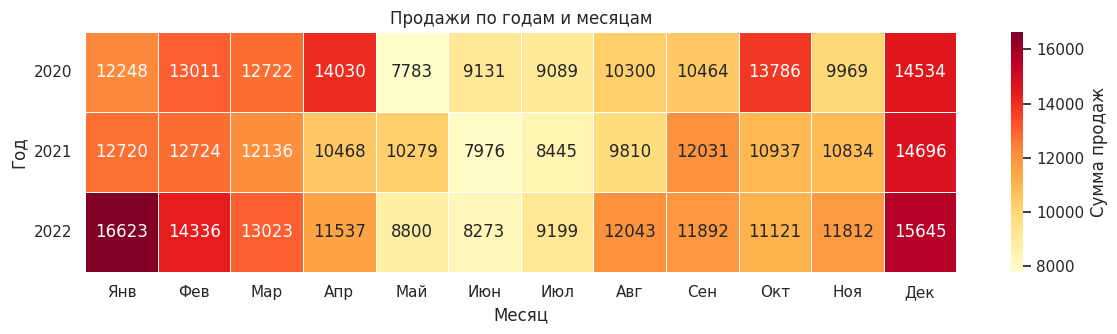

In [8]:
month_names = [
    "Янв", "Фев", "Мар", "Апр", "Май", "Июн",
    "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"
]

plot_data = train.assign(
    Year=train.index.year,
    Month=train.index.month
)

heatmap_data = plot_data.pivot(
    index="Year",
    columns="Month",
    values="SalesAmount"
)

fig, ax = plt.subplots(figsize=(12, 3.5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    xticklabels=month_names,
    cbar_kws={"label": "Сумма продаж"},
    ax=ax
)

ax.set(
    title="Продажи по годам и месяцам",
    xlabel="Месяц",
    ylabel="Год"
)
ax.tick_params(axis="y", labelrotation=0)

plt.tight_layout()
plt.show()

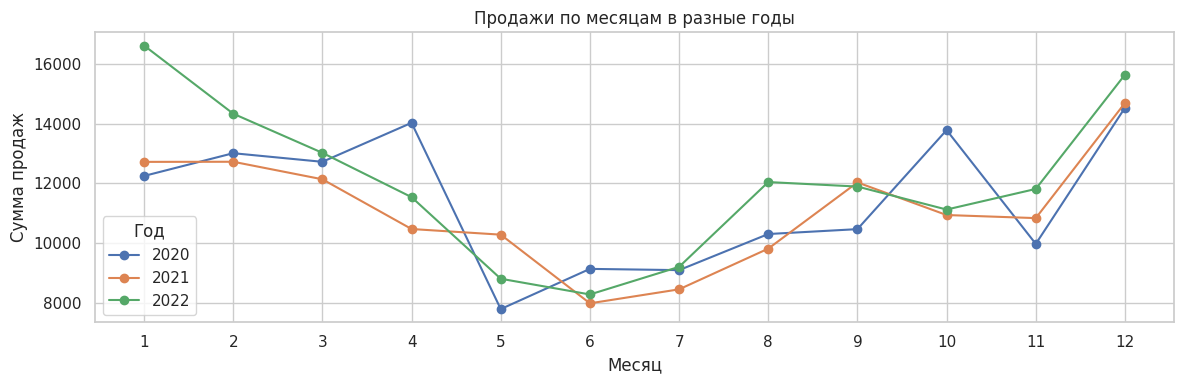

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))

for year, group in train.groupby(train.index.year):
    ax.plot(
        group.index.month,
        group["SalesAmount"],
        marker="o",
        label=str(year)
    )

ax.set(
    title="Продажи по месяцам в разные годы",
    xlabel="Месяц",
    ylabel="Сумма продаж",
    xticks=range(1, 13)
)
ax.legend(title="Год")

plt.tight_layout()
plt.show()

In [11]:
for feature in ["Promotion", "HolidayMonth"]:
    print(f"Группировка по {feature}")

    display(
        train.groupby(feature)["SalesAmount"]
        .agg(["count", "mean", "median"])
        .round(2)
    )

Группировка по Promotion


,count,mean,median
Promotion,,,
0,31,11308.97,11537.0
1,5,12769.80,13786.0


Группировка по HolidayMonth


,count,mean,median
HolidayMonth,,,
0,33,11198.55,11121.0
1,3,14958.33,14696.0


### Выводы по предварительному анализу

- Обучающая выборка содержит 36 месяцев. Средние продажи составляют 11 511,86, минимальные — 7 783, максимальные — 16 623.
- В разные годы повторяются снижение продаж в мае–июле и подъём в декабре. Это указывает на возможную годовую сезонность с периодом 12 месяцев.
- Устойчивый рост на протяжении всего периода не очевиден. Тренд уточним когда будем делать декомпозицию.
- В месяцы с акциями средние продажи выше: 12 769,80 против 11 308,97. Однако таких месяцев мало(только 5), и сравнение средних не доказывает причинного влияния акций.
- HolidayMonth равен 1 только в декабре, поэтому связь этого признака с продажами пересекается с годовой сезонностью.

## Классическая аддитивная/мультипликативная/stl декомпозиция

Рассмотрим структуру продаж тремя способами: декомпозицией на тренд,
сезонность и остаток, спектральным анализом Фурье и вейвлет-анализом.

Дополнительно построим ACF и PACF. ACF показывает связь значений ряда
с предыдущими наблюдениями, а PACF — связь на выбранном лаге после
учёта промежуточных лагов.

Для месячных данных проверяем наличие годовой сезонности с периодом 12.

In [12]:
%pip -q install statsmodels PyWavelets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

from scipy.signal import detrend
from scipy.fft import rfft, rfftfreq
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL

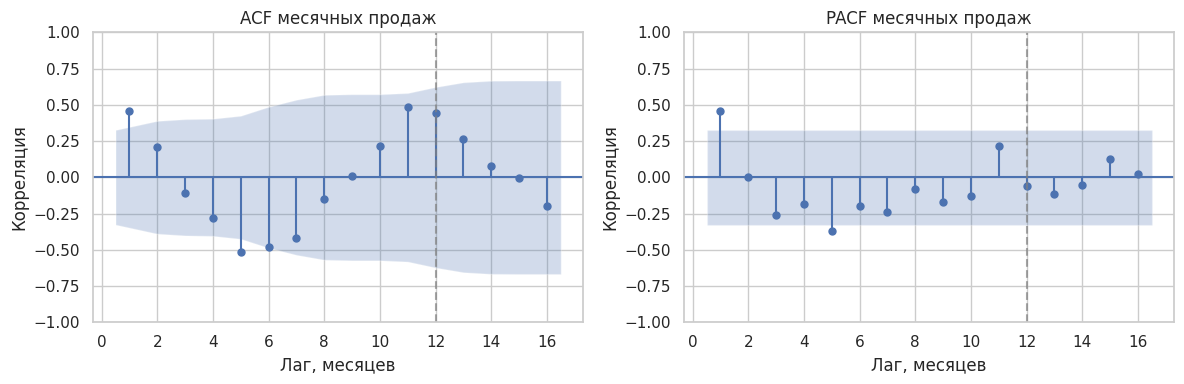

In [13]:
lags = min(16, len(y_train) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(
    y_train, lags=lags, zero=False,
    ax=axes[0], title="ACF месячных продаж"
)

plot_pacf(
    y_train, lags=lags, method="ywm", zero=False,
    ax=axes[1], title="PACF месячных продаж"
)

for ax in axes:
    ax.axvline(12, color="gray", linestyle="--", alpha=0.7)
    ax.set_xlabel("Лаг, месяцев")
    ax.set_ylabel("Корреляция")

plt.tight_layout()
plt.show()

ACF на лаге 12 составляет примерно 0,44, что согласуется
с повторением годового рисунка продаж. Однако этот коэффициент
находится внутри показанной 95%-й доверительной полосы.

В PACF выделяются первый и пятый лаги. Однозначно определить
порядок модели по этим графикам нельзя, особенно на выборке
из 36 наблюдений.

In [23]:
from statsmodels.tsa.stattools import adfuller, kpss

adf_result = adfuller(y_train, regression="c", autolag="AIC")
kpss_result = kpss(y_train, regression="c", nlags="auto")

# 0.1 — верхняя граница табличных p-value KPSS
kpss_p_text = (
    "> 0.1"
    if kpss_result[1] == 0.1
    else f"{kpss_result[1]:.4f}"
)

print(
    f"ADF: статистика = {adf_result[0]:.4f}, "
    f"p-value = {adf_result[1]:.4f}"
)
print(
    f"KPSS: статистика = {kpss_result[0]:.4f}, "
    f"p-value {kpss_p_text}"
)

ADF: статистика = -3.7700, p-value = 0.0032
KPSS: статистика = 0.0576, p-value > 0.1


/tmp/ipykernel_830/3426297003.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(y_train, regression="c", autolag="AIC")
/tmp/ipykernel_830/3426297003.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(y_train, regression="c", nlags="auto")
/tmp/ipykernel_830/3426297003.py:4: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch

ADF отвергает гипотезу обычного единичного корня: p-value ≈ 0,0032.
KPSS не отвергает гипотезу стационарности вокруг постоянного уровня:
p-value > 0,1.

Результаты позволяют рассмотреть d=0 как начальный вариант модели.
Однако они не доказывают отсутствие сезонности: годовой рисунок
продаж необходимо учитывать отдельно.

Период сезонности принимаем кандидатом s=12. Необходимость сезонной
разности и значение D будем оценивать на этапе построения моделей.

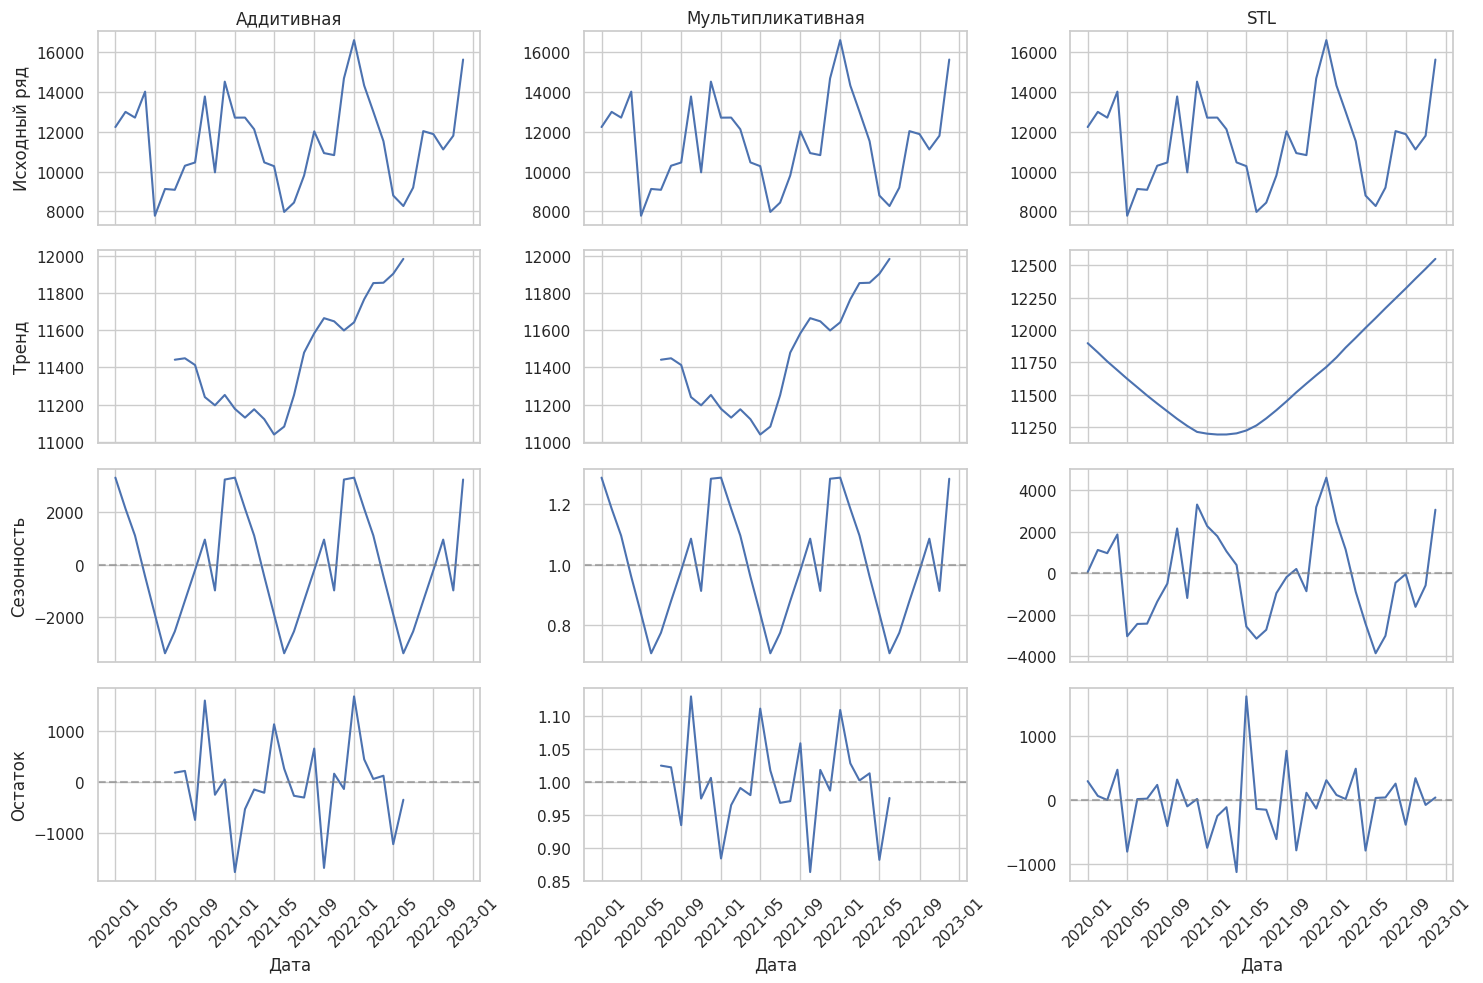

In [20]:
decompositions = {
    "Аддитивная": seasonal_decompose(
        y_train, model="additive", period=12
    ),
    "Мультипликативная": seasonal_decompose(
        y_train, model="multiplicative", period=12
    ),
    "STL": STL(
    y_train,
    period=12,
    seasonal=7,
    robust=False
    ).fit()
}

labels = ["Исходный ряд", "Тренд", "Сезонность", "Остаток"]

fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharex=True)

for col, (name, result) in enumerate(decompositions.items()):
    components = [
        y_train, result.trend, result.seasonal, result.resid
    ]

    for row, values in enumerate(components):
        ax = axes[row, col]
        ax.plot(values.index, values, linewidth=1.5)

        if col == 0:
            ax.set_ylabel(labels[row])

        if row == 0:
            ax.set_title(name)

        if row >= 2:
            baseline = 1 if name == "Мультипликативная" else 0
            ax.axhline(
                baseline, color="gray", linestyle="--", alpha=0.6
            )

    axes[-1, col].set_xlabel("Дата")
    axes[-1, col].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Сравниваем исходные продажи с трендом и сезонностью без остатка.
# Даты берём одинаковые для всех методов, а ошибки считаем в исходных единицах продаж.
add = decompositions["Аддитивная"]
mul = decompositions["Мультипликативная"]
stl = decompositions["STL"]

reconstructed = pd.DataFrame({
    "Аддитивная": add.trend + add.seasonal,
    "Мультипликативная": mul.trend * mul.seasonal,
    "STL": stl.trend + stl.seasonal
})

# Оставляем общие даты с определённым трендом.
common = reconstructed.join(y_train.rename("Факт")).dropna()
errors = common.drop(columns="Факт").sub(common["Факт"], axis=0)

decomposition_metrics = pd.DataFrame({
    "MAE": errors.abs().mean(),
    "MSE": errors.pow(2).mean()
})

print(f"Количество месяцев для сравнения: {len(common)}")
display(decomposition_metrics.round(2))

Количество месяцев для сравнения: 24


,MAE,MSE
Аддитивная,589.37,671862.00
Мультипликативная,569.49,637716.68
STL,391.00,313093.38


Все разложения отражают повышение продаж зимой и снижение
в конце весны и начале лета. Классические методы используют
повторяющийся сезонный профиль, а STL допускает его изменение.

В робастном варианте STL все месяцы 2021 года получили нулевые веса.
Поэтому для этого короткого ряда выбран обычный STL с robust=False.

Сравнение выполнено на 24 общих месяцах. Наименьшие ошибки восстановления
получены у STL: MAE = 391,00, MSE = 313 093,38.
Мультипликативная декомпозиция немного точнее аддитивной.

Эти ошибки характеризуют приближение обучающих данных трендом
и сезонностью, а не качество прогноза. При наличии только трёх
годовых циклов STL может относить часть случайных колебаний
к сезонной компоненте.

## Спектральный анализ и FFT

Перейдём к FFT: преобразование Фурье разделяет ряд на колебания
разных частот. В отличие от предыдущего подхода, годовой период
здесь заранее не задаётся.

Перед FFT удалим линейный тренд и применим окно Ханна для уменьшения
спектральной утечки — распределения энергии колебания по соседним частотам.

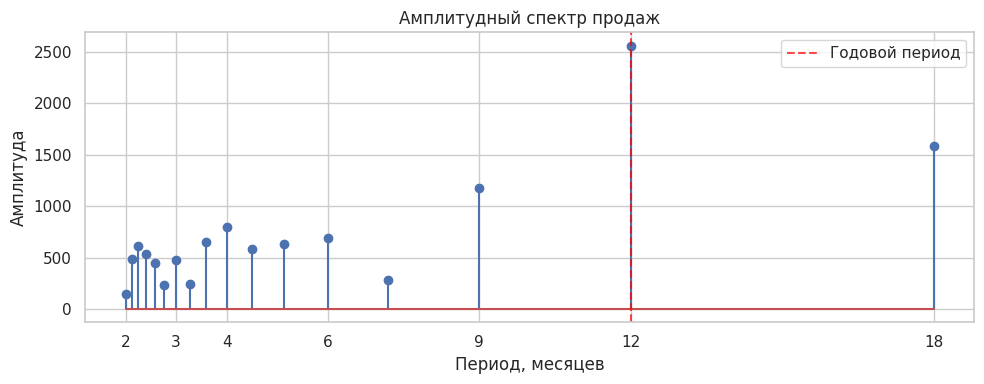

,"Период, месяцев",Амплитуда
2,12.0,2560.78
1,18.0,1585.75
3,9.0,1176.85
8,4.0,796.11
5,6.0,692.01


In [18]:
x = y_train.to_numpy(dtype=float)
n = len(x)

x_detrended = detrend(x, type="linear")
window = np.hanning(n)

fft_values = rfft(x_detrended * window)
frequencies = rfftfreq(n, d=1)  # Частота в циклах за месяц

amplitudes = 2 * np.abs(fft_values) / window.sum()

if n % 2 == 0:
    amplitudes[-1] /= 2

# Исключаем нулевую частоту и переводим частоты в периоды
spectrum = pd.DataFrame({
    "Период, месяцев": 1 / frequencies[1:],
    "Амплитуда": amplitudes[1:]
})

# Показываем периоды, для которых наблюдаются хотя бы два цикла
spectrum = spectrum[spectrum["Период, месяцев"] <= n / 2]

fig, ax = plt.subplots(figsize=(10, 4))

ax.stem(spectrum["Период, месяцев"], spectrum["Амплитуда"])
ax.axvline(
    12, color="red", linestyle="--", alpha=0.7,
    label="Годовой период"
)

ax.set(
    title="Амплитудный спектр продаж",
    xlabel="Период, месяцев",
    ylabel="Амплитуда"
)
ax.set_xticks([2, 3, 4, 6, 9, 12, 18])
ax.legend()

plt.tight_layout()
plt.show()

display(spectrum.nlargest(5, "Амплитуда").round(2))

Максимальная амплитуда FFT соответствует периоду 12 месяцев,
что подтверждает выраженность годовой сезонности.

Соседние пики на 9 и 18 месяцах нельзя сразу считать самостоятельными
циклами: короткая выборка и применение окна ограничивают частотное
разрешение анализа.

FFT описывает частоты за весь рассматриваемый интервал.
Вейвлет-анализ дополнительно показывает, в какие моменты времени
проявляются колебания разных периодов. Поэтому перейдем к нему



## Вейвлет-анализ
Используем комплексный вейвлет Морле. На графике по горизонтали
будет время, по вертикали — период колебаний в месяцах,
а цветом будет показана их мощность.

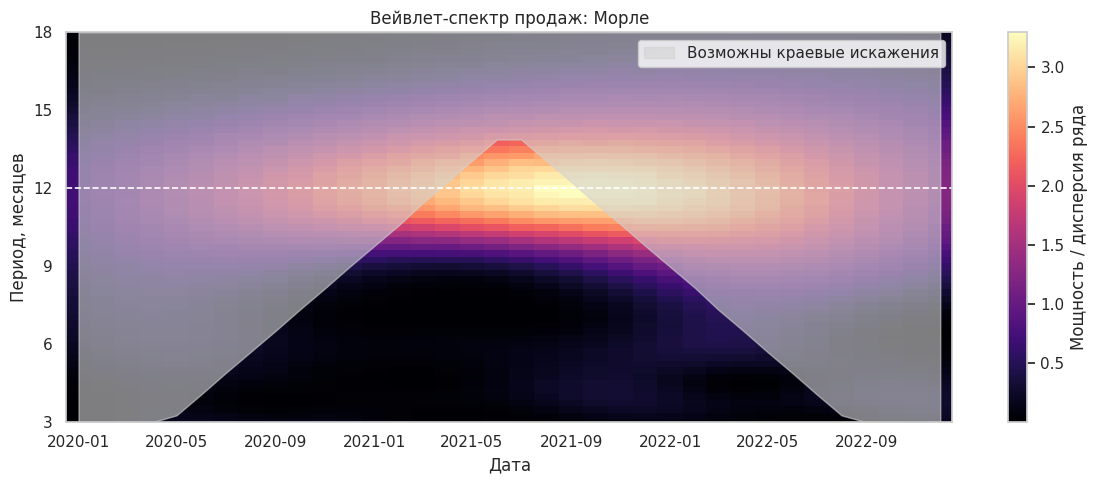

In [19]:
#Масштабы переводим в периоды через функции PyWavelets.
# Серым обозначим приближённую область краевых эффектов: на длинных периодах она особенно велика для короткого ряда.
wavelet = "cmor1.5-1.0"
target_periods = np.linspace(3, 18, 61)

scales = pywt.frequency2scale(wavelet, 1 / target_periods)

coefficients, wavelet_frequencies = pywt.cwt(
    x_detrended,
    scales,
    wavelet,
    sampling_period=1,
    method="fft"
)

wavelet_periods = 1 / wavelet_frequencies
power = np.abs(coefficients) ** 2 / np.var(x_detrended)

fig, ax = plt.subplots(figsize=(12, 5))

mesh = ax.pcolormesh(
    y_train.index,
    wavelet_periods,
    power,
    shading="auto",
    cmap="magma"
)

# Приближённая граница по ширине выбранного вейвлета Морле
edge_distance = np.minimum(np.arange(n), np.arange(n)[::-1])
edge_period = edge_distance / (
    np.sqrt(1.5) * pywt.central_frequency(wavelet)
)

ax.fill_between(
    y_train.index,
    np.clip(edge_period, 3, 18),
    18,
    color="lightgray",
    alpha=0.6,
    label="Возможны краевые искажения"
)

ax.axhline(12, color="white", linestyle="--", linewidth=1.2)

ax.set(
    title="Вейвлет-спектр продаж: Морле",
    xlabel="Дата",
    ylabel="Период, месяцев",
    ylim=(3, 18)
)
ax.set_yticks([3, 6, 9, 12, 15, 18])
ax.legend(loc="upper right")

fig.colorbar(mesh, ax=ax, label="Мощность / дисперсия ряда")

plt.tight_layout()
plt.show()

Вейвлет-спектр показывает выраженную область мощности около периода
12 месяцев в центральной части ряда. Это согласуется с результатом FFT.
Изменения мощности у границ нельзя уверенно объяснять усилением
или ослаблением сезонности: там существенны краевые эффекты.

| Метод | Применимость к ряду | Преимущества | Ограничения |
|---|---|---|---|
| Аддитивная декомпозиция | Описывает сезонные отклонения продаж в абсолютных величинах | Простая интерпретация компонент | Фиксированный сезонный профиль; пропуски тренда на краях |
| Мультипликативная декомпозиция | Допустима, поскольку все продажи положительны; полезна при росте сезонной амплитуды вместе с уровнем | Описывает относительные сезонные изменения | Требует положительных значений; пропорциональность амплитуды уровню здесь убедительно не установлена |
| STL | Подходит для выделения тренда и годовой сезонности | Гибкое сглаживание; устойчивый вариант уменьшает влияние выбросов | Результат зависит от настроек; три цикла ограничивают оценку изменений сезонности |
| FFT | Выявляет доминирующий период 12 месяцев | Позволяет искать периодичность без предварительного задания периода | Не показывает время возникновения колебаний; на коротком ряду низкое частотное разрешение |
| Вейвлет Морле | Показывает годовые колебания с привязкой ко времени | Совмещает анализ периода и времени | Сильные краевые эффекты; результат зависит от вейвлета и масштабов |

Для интерпретации компонент удобно использовать STL, а FFT —
для проверки доминирующего периода. Вейвлет-анализ дополняет их,
но 36 наблюдений недостаточно для уверенных выводов об изменении
силы годовой сезонности.

Годовой период 12 месяцев следует рассмотреть при построении сезонной
модели прогнозирования. Качество прогноза будем оценивать отдельно.

# 3. Построение прогнозных моделей

По результатам EDA основной сезонный период составляет 12 месяцев.
Тесты ADF и KPSS позволяют рассмотреть обычный порядок
дифференцирования d=0; варианты с d=1 проверим дополнительно.

Для ARIMA рассмотрим небольшие порядки p и q, а также p=5,
поскольку на PACF наблюдался заметный коэффициент на пятом лаге.
Для SARIMAX проверим сезонную разность и сезонные AR/MA-компоненты.

Параметры выбираем внутри обучающей выборки:
- обучение кандидатов: 2020–2021 годы;
- валидация: 2022 год;
- окончательное обучение выбранных моделей: 2020–2022 годы;
- тестирование: 2023 год.

Основной критерий выбора — MAE на валидации. Если ошибка отличается
от минимальной не более чем на 5%, предпочитаем модель
с меньшим числом оцениваемых параметров.

In [24]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

y_train = train["SalesAmount"].astype(float)
y_test = test["SalesAmount"].astype(float)

X_train = train[["Promotion"]].astype(float)
X_test = test[["Promotion"]].astype(float)

y_fit = y_train.iloc[:-12]
y_valid = y_train.iloc[-12:]

X_fit = X_train.loc[y_fit.index]
X_valid = X_train.loc[y_valid.index]

MAPE_LIMIT = 10.0

print(f"Обучение кандидатов: {len(y_fit)} месяцев")
print(f"Валидация: {len(y_valid)} месяцев")
print(f"Окончательное обучение: {len(y_train)} месяцев")
print(f"Тест: {len(y_test)} месяцев")

Обучение кандидатов: 24 месяцев
Валидация: 12 месяцев
Окончательное обучение: 36 месяцев
Тест: 12 месяцев


В SARIMAX используем внешний признак Promotion.

HolidayMonth совпадает с декабрём и при сезонной разности с лагом 12
обнуляется. Поэтому в рассматриваемые модели включаем только Promotion.

Прогноз SARIMAX строится при допущении, что план акций известен заранее.


In [25]:
arima_orders = [
    (0, 0, 0),
    (1, 0, 0),
    (2, 0, 0),
    (5, 0, 0),
    (1, 0, 1),
    (0, 1, 1),
    (1, 1, 0)
]

# order, seasonal_order, наличие константы
sarimax_options = [
    ((0, 0, 0), (0, 1, 0, 12), "n"),
    ((0, 0, 0), (0, 1, 0, 12), "c"),
    ((1, 0, 0), (0, 1, 0, 12), "c"),
    ((0, 0, 1), (0, 1, 0, 12), "c"),
    ((0, 0, 0), (0, 1, 1, 12), "c"),
    ((0, 0, 0), (1, 0, 0, 12), "c"),
    ((1, 0, 0), (1, 0, 0, 12), "c")
]

candidates = [
    {
        "family": "ARIMA",
        "order": order,
        "seasonal_order": (0, 0, 0, 0),
        "trend": "c" if order[1] == 0 else "n"
    }
    for order in arima_orders
]

candidates += [
    {
        "family": "SARIMAX",
        "order": order,
        "seasonal_order": seasonal,
        "trend": trend
    }
    for order, seasonal, trend in sarimax_options
]


def fit_candidate(spec, y, X):
    if spec["family"] == "ARIMA":
        result = ARIMA(
            y,
            order=spec["order"],
            trend=spec["trend"]
        ).fit(method_kwargs={"maxiter": 300})
    else:
        result = SARIMAX(
            y,
            exog=X,
            order=spec["order"],
            seasonal_order=spec["seasonal_order"],
            trend=spec["trend"]
        ).fit(disp=False, maxiter=300)

    if not result.mle_retvals.get("converged", True):
        raise RuntimeError("Оптимизация не сошлась")

    return result

In [28]:
rows = []

for candidate_id, spec in enumerate(candidates):
    row = {
        "id": candidate_id,
        **spec,
        # k — число оцениваемых параметров, включая дисперсию ошибки
        "k": np.nan,
        "MAE_val": np.nan,
        "status": "OK"
    }

    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")

            fitted = fit_candidate(spec, y_fit, X_fit)

            forecast_kwargs = (
                {"exog": X_valid}
                if spec["family"] == "SARIMAX"
                else {}
            )

            pred = fitted.get_forecast(
                steps=len(y_valid),
                **forecast_kwargs
            ).predicted_mean

        for warning in caught:
            print(f"Кандидат {candidate_id}: {warning.message}")

        if not np.isfinite(pred).all():
            raise ValueError("Прогноз содержит некорректные значения")

        row["k"] = len(fitted.params)
        row["MAE_val"] = (y_valid - pred).abs().mean()

    except (ValueError, RuntimeError, np.linalg.LinAlgError) as error:
        row["status"] = str(error)

    rows.append(row)

search_results = pd.DataFrame(rows)

display(
    search_results
    .sort_values(["family", "MAE_val"])
    .round(2)
)

Кандидат 11: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
Кандидат 13: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).


,id,family,order,seasonal_order,trend,k,MAE_val,status
3,3,ARIMA,"(5, 0, 0)","(0, 0, 0, 0)",c,7,1717.54,OK
2,2,ARIMA,"(2, 0, 0)","(0, 0, 0, 0)",c,4,1880.09,OK
4,4,ARIMA,"(1, 0, 1)","(0, 0, 0, 0)",c,4,1900.77,OK
1,1,ARIMA,"(1, 0, 0)","(0, 0, 0, 0)",c,3,1919.78,OK
0,0,ARIMA,"(0, 0, 0)","(0, 0, 0, 0)",c,2,2041.45,OK
5,5,ARIMA,"(0, 1, 1)","(0, 0, 0, 0)",n,2,2711.72,OK
6,6,ARIMA,"(1, 1, 0)","(0, 0, 0, 0)",n,2,2759.70,OK
10,10,SARIMAX,"(0, 0, 1)","(0, 1, 0, 12)",c,4,872.04,OK
11,11,SARIMAX,"(0, 0, 0)","(0, 1, 1, 12)",c,4,887.11,OK
8,8,SARIMAX,"(0, 0, 0)","(0, 1, 0, 12)",c,3,889.67,OK


In [29]:
best_specs = {}
selected_rows = []

for family in ["ARIMA", "SARIMAX"]:
    group = search_results[
        (search_results["family"] == family)
        & (search_results["status"] == "OK")
    ].copy()

    if group.empty:
        raise RuntimeError(f"Нет успешно обученных моделей {family}")

    # Среди близких по ошибке вариантов выбираем более простой
    eligible = group[
        group["MAE_val"] <= 1.05 * group["MAE_val"].min()
    ]

    best = eligible.sort_values(["k", "MAE_val"]).iloc[0]

    best_specs[family] = candidates[int(best["id"])]
    selected_rows.append(best)

selection_table = pd.DataFrame(selected_rows).set_index("family")

display(
    selection_table[
        ["order", "seasonal_order", "trend", "k", "MAE_val"]
    ].round(2)
)

,order,seasonal_order,trend,k,MAE_val
family,,,,,
ARIMA,"(5, 0, 0)","(0, 0, 0, 0)",c,7,1717.54
SARIMAX,"(0, 0, 0)","(0, 1, 0, 12)",c,3,889.67


По внутренней валидации выбрана ARIMA(5,0,0) с константой.

Для SARIMAX выбрана конфигурация (0,0,0)(0,1,0,12)
с константой и признаком Promotion. Сезонность в ней учитывается
через разность с лагом 12, поэтому нулевые значения P и Q
не означают отсутствия сезонной структуры.

Выбранные конфигурации переобучаем на всех 36 месяцах
обучающей выборки.

In [31]:
models = {
    family: fit_candidate(spec, y_train, X_train)
    for family, spec in best_specs.items()
}

forecast_results = {}
predictions = pd.DataFrame(index=y_test.index)

for family, model in models.items():
    forecast_kwargs = (
        {"exog": X_test}
        if family == "SARIMAX"
        else {}
    )

    forecast_results[family] = model.get_forecast(
        steps=len(y_test),
        **forecast_kwargs
    )

    predictions[family] = (
        forecast_results[family].predicted_mean
    )

# Наивный прогноз строится только из обучающей выборки.
# np.resize позволяет повторять последний известный год и при более длинном горизонте.
predictions["Сезонный наивный"] = np.resize(
    y_train.iloc[-12:].to_numpy(),
    len(y_test)
)

forecast_table = predictions.copy()
forecast_table.insert(0, "Факт", y_test)

display(forecast_table.round(2))

,Факт,ARIMA,SARIMAX,Сезонный наивный
Date,,,,
2023-01-01,13904.0,12862.96,14402.62,16623.0
2023-02-01,13901.0,11930.74,14868.14,14336.0
2023-03-01,13534.0,11368.32,13555.14,13023.0
2023-04-01,12048.0,11454.50,12069.14,11537.0
2023-05-01,12949.0,9586.30,12084.67,8800.0
2023-06-01,9104.0,10222.78,8805.14,8273.0
2023-07-01,10042.0,10761.51,9731.14,9199.0
2023-08-01,11566.0,11507.42,12575.14,12043.0
2023-09-01,11759.0,11539.66,12424.14,11892.0


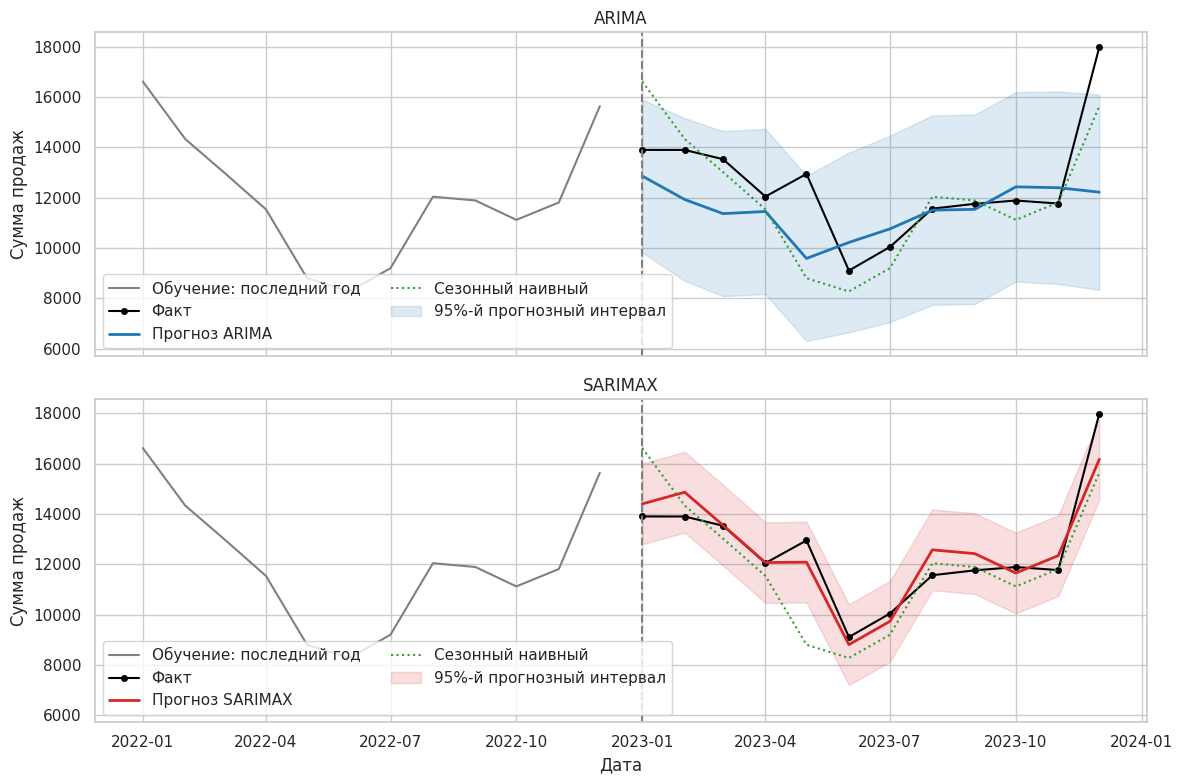

In [32]:
fig, axes = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, sharey=True
)

colors = {"ARIMA": "tab:blue", "SARIMAX": "tab:red"}

for ax, family in zip(axes, ["ARIMA", "SARIMAX"]):
    interval = forecast_results[family].conf_int(alpha=0.05)

    ax.plot(
        y_train.iloc[-12:],
        color="gray",
        label="Обучение: последний год"
    )

    ax.plot(
        y_test,
        color="black",
        marker="o",
        markersize=4,
        label="Факт"
    )

    ax.plot(
        predictions[family],
        color=colors[family],
        linewidth=2,
        label=f"Прогноз {family}"
    )

    ax.plot(
        predictions["Сезонный наивный"],
        color="tab:green",
        linestyle=":",
        label="Сезонный наивный"
    )

    ax.fill_between(
        interval.index,
        interval.iloc[:, 0],
        interval.iloc[:, 1],
        color=colors[family],
        alpha=0.15,
        label="95%-й прогнозный интервал"
    )

    ax.axvline(y_test.index[0], color="gray", linestyle="--")
    ax.set(title=family, ylabel="Сумма продаж")
    ax.legend(ncol=2)

axes[-1].set_xlabel("Дата")

plt.tight_layout()
plt.show()

Приемлемым качеством в этой работе считаем MAPE не выше 10%.

Для каждого горизонта h рассчитываем среднюю абсолютную процентную
ошибку по первым h месяцам прогноза.

Допустимым считаем максимальный горизонт H, для которого порог
соблюдается на всех промежуточных горизонтах от 1 до H.


,ARIMA,SARIMAX,Сезонный наивный
"Горизонт, месяцев",,,
1,7.49,3.59,19.56
2,10.83,5.27,11.34
3,12.55,3.57,8.82
4,10.65,2.72,7.68
5,13.71,3.51,12.55
6,13.47,3.47,11.98
7,12.57,3.42,11.47
8,11.06,4.08,10.55
9,10.04,4.26,9.50


,"MAPE за весь тест, %","Допустимый горизонт, месяцев"
ARIMA,11.03,1
SARIMAX,4.61,12


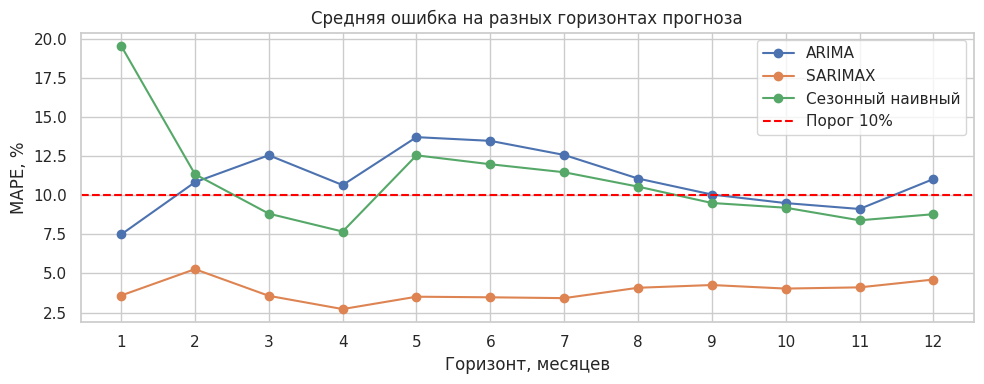

In [33]:
absolute_percentage_errors = (
    predictions
    .sub(y_test, axis=0)
    .abs()
    .div(y_test.abs(), axis=0)
    * 100
)

# Средняя ошибка по первым h месяцам
horizon_mape = absolute_percentage_errors.expanding().mean()
horizon_mape.index = pd.RangeIndex(
    1, len(y_test) + 1, name="Горизонт, месяцев"
)

display(horizon_mape.round(2))

max_horizons = {}

for family in models:
    # После первого превышения более длинный горизонт не принимаем
    acceptable = horizon_mape[family].cummax() <= MAPE_LIMIT
    max_horizons[family] = int(acceptable.sum())

horizon_summary = pd.DataFrame({
    "MAPE за весь тест, %": horizon_mape.iloc[-1][list(models)],
    "Допустимый горизонт, месяцев": pd.Series(max_horizons)
})

display(horizon_summary.round(2))

fig, ax = plt.subplots(figsize=(10, 4))

horizon_mape.plot(ax=ax, marker="o")

ax.axhline(
    MAPE_LIMIT,
    color="red",
    linestyle="--",
    label=f"Порог {MAPE_LIMIT:g}%"
)

ax.set(
    title="Средняя ошибка на разных горизонтах прогноза",
    xlabel="Горизонт, месяцев",
    ylabel="MAPE, %",
    xticks=range(1, len(y_test) + 1)
)
ax.legend()

plt.tight_layout()
plt.show()

После обучения на 2020–2022 годах модели сформировали прогноз
на 12 месяцев 2023 года.

SARIMAX воспроизводит годовой профиль продаж и учитывает
различия в проведении акций. MAPE за тестовый год составляет
около 4,61%. Порог 10% соблюдается на всех проверенных горизонтах,
поэтому максимальный подтверждённый горизонт равен 12 месяцам.

ARIMA имеет MAPE около 11,03% за год и существенно недооценивает
декабрьский пик. По принятому правилу допустимый горизонт
для неё составляет один месяц.

Полученная оценка относится к одному тестовому году
и предполагает заранее известный план акций.

## 4. Оценка качества моделей

Для оценки прогноза используем требуемые в задании метрики MSE и R².
Дополнительно сохраняем MAE и MAPE, которые уже использовались при выборе допустимого горизонта.

AIC и BIC берём из результатов обученных моделей. Для обоих критериев меньшее значение предпочтительнее: они сопоставляют качество описания обучающих данных и сложность модели. При выборе прогнозной модели информационные критерии рассматриваем вместе с качеством на отложенном тесте.

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

# Сравниваем обе модели на одном и том же тестовом интервале 2023 года
quality_rows = []

for family in ["ARIMA", "SARIMAX"]:
    y_pred = predictions[family]

    quality_rows.append({
        "Модель": family,
        "MSE": mean_squared_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred),
        "MAE": (y_test - y_pred).abs().mean(),
        "MAPE, %": ((y_test - y_pred).abs() / y_test.abs()).mean() * 100,
        "AIC": models[family].aic,
        "BIC": models[family].bic,
    })

quality_table = (
    pd.DataFrame(quality_rows)
    .set_index("Модель")
)

display(quality_table.round(3))


,MSE,R²,MAE,"MAPE, %",AIC,BIC
Модель,,,,,,
ARIMA,4763304.556,-0.030,1516.353,11.032,650.951,662.036
SARIMAX,606056.300,0.869,607.187,4.607,396.066,399.601


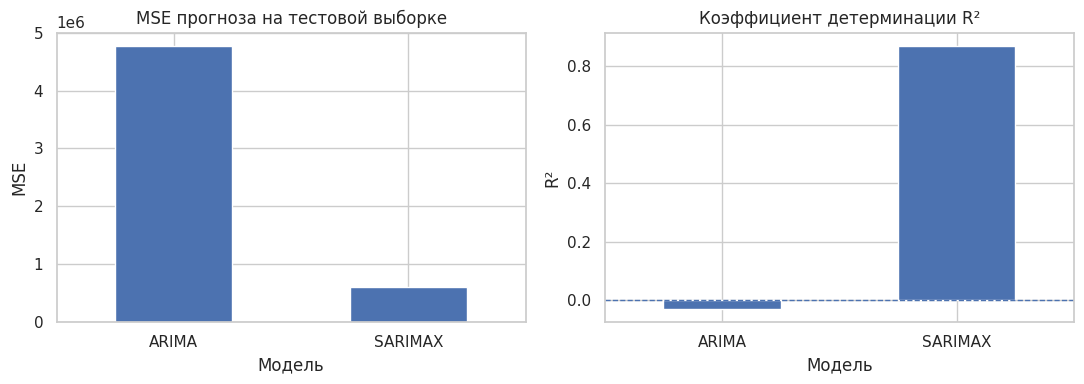

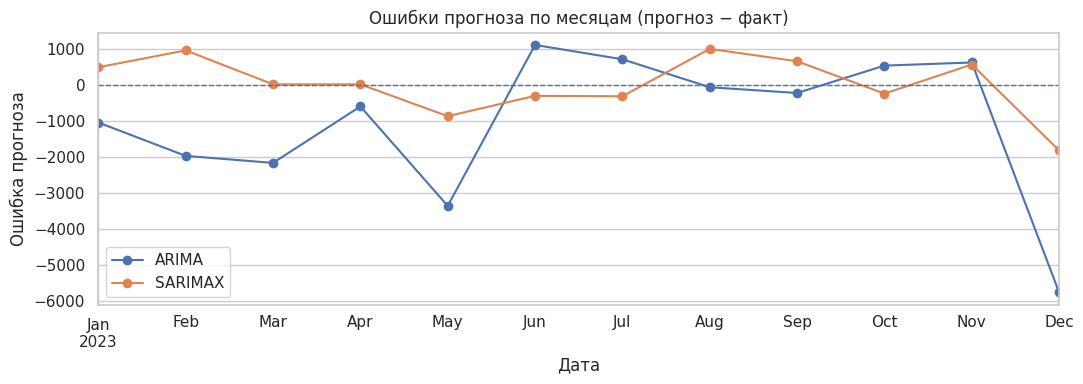

In [35]:
# Графически сравним MSE и R²
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

quality_table["MSE"].plot(kind="bar", ax=axes[0])
axes[0].set(
    title="MSE прогноза на тестовой выборке",
    xlabel="Модель",
    ylabel="MSE"
)
axes[0].tick_params(axis="x", rotation=0)

quality_table["R²"].plot(kind="bar", ax=axes[1])
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set(
    title="Коэффициент детерминации R²",
    xlabel="Модель",
    ylabel="R²"
)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Ошибка по времени помогает увидеть месяцы, где модель систематически промахивается
forecast_errors = predictions[["ARIMA", "SARIMAX"]].sub(y_test, axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
forecast_errors.plot(ax=ax, marker="o")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(
    title="Ошибки прогноза по месяцам (прогноз − факт)",
    xlabel="Дата",
    ylabel="Ошибка прогноза"
)
plt.tight_layout()
plt.show()


## 4.2. Анализ остатков
Для остатков проверяем три свойства:
- нормальность — тест Шапиро—Уилка;
- отсутствие автокорреляции — тест Льюнга—Бокса;
- гомоскедастичность — ARCH LM-тест на зависимость дисперсии остатков во времени.

Во всех тестах используем уровень значимости α = 0,05. Если p-value > 0,05, соответствующую нулевую гипотезу не отвергаем. Для SARIMAX первые наблюдения, относящиеся к периоду инициализации сезонной модели, исключаем из диагностики через `loglikelihood_burn`.

In [36]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.gofplots import qqplot

ALPHA = 0.05


def get_diagnostic_residuals(result):
    """Удаляем пропуски и начальный период diffuse/burn-in инициализации модели."""
    resid = pd.Series(result.resid).dropna()
    burn = int(getattr(result, "loglikelihood_burn", 0))

    if burn > 0 and len(resid) > burn:
        resid = resid.iloc[burn:]

    return resid


residuals_by_model = {}
diagnostic_rows = []

for family in ["ARIMA", "SARIMAX"]:
    result = models[family]
    resid = get_diagnostic_residuals(result)
    residuals_by_model[family] = resid

    # Нормальность остатков: H0 — распределение нормально
    shapiro_stat, shapiro_p = shapiro(resid)

    # Автокорреляция: H0 — автокорреляции до выбранного лага отсутствуют
    p, d, q = best_specs[family]["order"]
    P, D, Q, s = best_specs[family]["seasonal_order"]
    model_df = p + q + P + Q
    lb_lag = min(12, len(resid) - 1)

    lb_result = acorr_ljungbox(
        resid,
        lags=[lb_lag],
        model_df=model_df,
        return_df=True
    )
    lb_p = lb_result["lb_pvalue"].iloc[0]

    # ARCH LM: H0 — условная дисперсия постоянна, ARCH-эффекта нет
    arch_lags = min(5, max(1, len(resid) // 4))
    arch_stat, arch_p, _, _ = het_arch(resid, nlags=arch_lags)

    diagnostic_rows.append({
        "Модель": family,
        "N остатков": len(resid),
        "Shapiro p": shapiro_p,
        f"Ljung-Box p (lag={lb_lag})": lb_p,
        f"ARCH LM p (lags={arch_lags})": arch_p,
        "Нормальность": "не отвергается" if shapiro_p > ALPHA else "отвергается",
        "Автокорреляция": "не выявлена" if lb_p > ALPHA else "выявлена",
        "Гетероскедастичность": "не выявлена" if arch_p > ALPHA else "выявлена",
    })

diagnostic_table = (
    pd.DataFrame(diagnostic_rows)
    .set_index("Модель")
)

display(diagnostic_table.round(4))


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


,N остатков,Shapiro p,Ljung-Box p (lag=12),ARCH LM p (lags=5),Нормальность,Автокорреляция,Гетероскедастичность
Модель,,,,,,,
ARIMA,36,0.7230,0.093,0.1637,не отвергается,не выявлена,не выявлена
SARIMAX,24,0.5219,0.411,0.9886,не отвергается,не выявлена,не выявлена


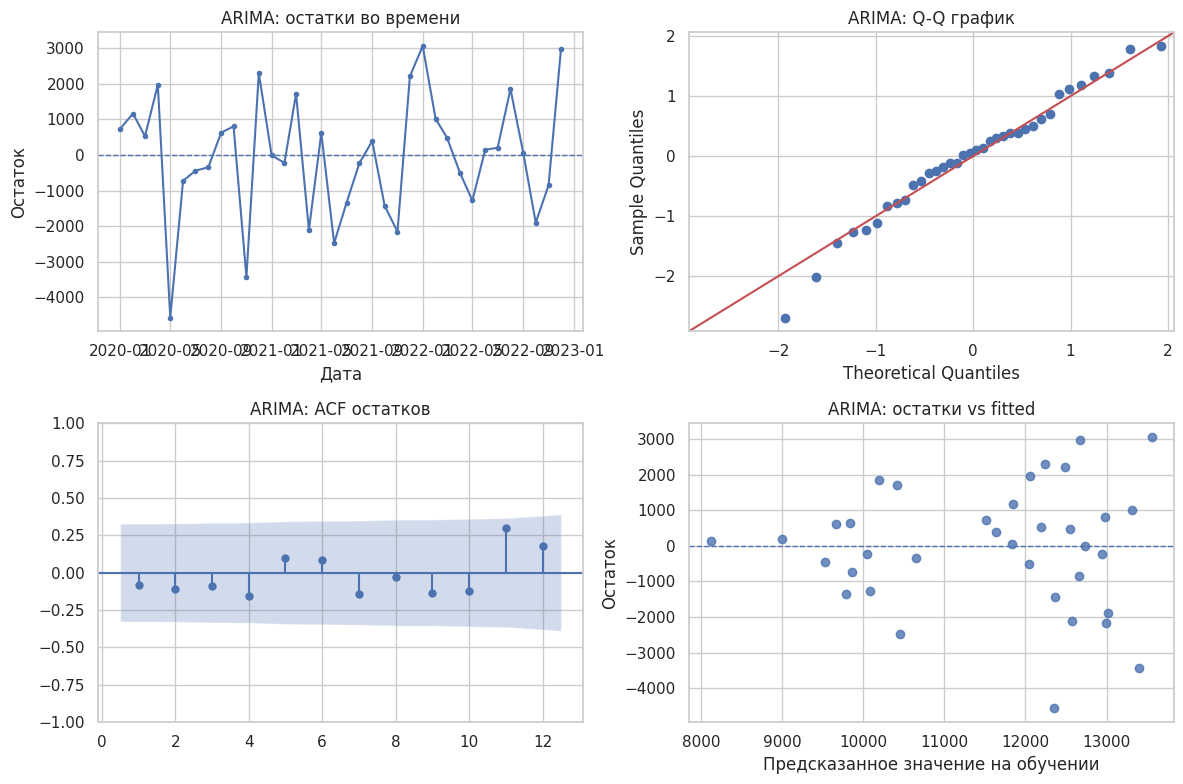

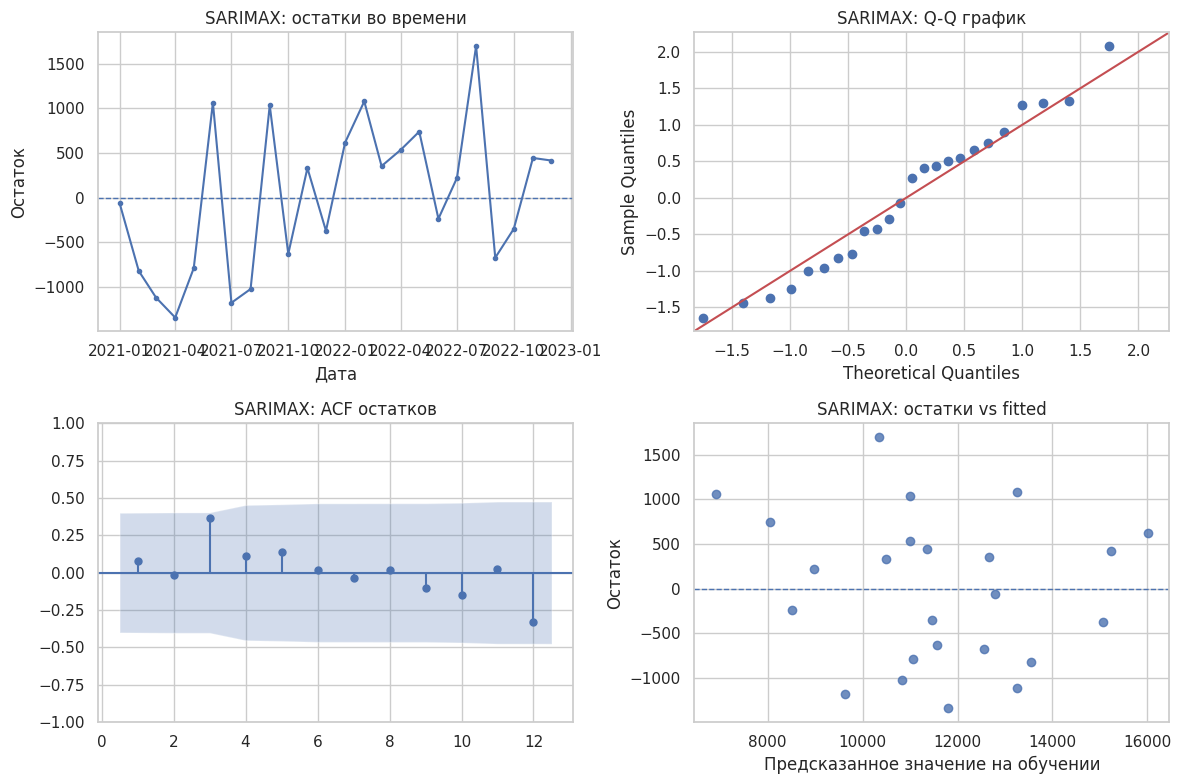

In [37]:
# Графическая диагностика остатков каждой модели
# 1) остатки во времени;
# 2) Q-Q график;
# 3) ACF;
# 4) остатки против fitted values.
for family in ["ARIMA", "SARIMAX"]:
    resid = residuals_by_model[family]
    fitted = pd.Series(models[family].fittedvalues).reindex(resid.index)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(resid.index, resid, marker="o", markersize=3)
    axes[0, 0].axhline(0, linestyle="--", linewidth=1)
    axes[0, 0].set(
        title=f"{family}: остатки во времени",
        xlabel="Дата",
        ylabel="Остаток"
    )

    qqplot(resid, line="45", ax=axes[0, 1], fit=True)
    axes[0, 1].set_title(f"{family}: Q-Q график")

    acf_lags = min(12, len(resid) - 1)
    plot_acf(
        resid,
        lags=acf_lags,
        zero=False,
        ax=axes[1, 0],
        title=f"{family}: ACF остатков"
    )

    axes[1, 1].scatter(fitted, resid, alpha=0.8)
    axes[1, 1].axhline(0, linestyle="--", linewidth=1)
    axes[1, 1].set(
        title=f"{family}: остатки vs fitted",
        xlabel="Предсказанное значение на обучении",
        ylabel="Остаток"
    )

    plt.tight_layout()
    plt.show()


На тестовом 2023 году SARIMAX заметно превосходит ARIMA по качеству прогноза. По уже полученным прогнозам:
- ARIMA: MSE ≈ 4 763 302, R² ≈ −0,030;
- SARIMAX: MSE ≈ 606 055, R² ≈ 0,869.

Таким образом, MSE у SARIMAX примерно в 7,9 раза ниже. Отрицательное R² у ARIMA означает, что по квадратичной ошибке её прогноз на этом тестовом отрезке хуже простого прогноза постоянным средним значением тестовой выборки. SARIMAX, напротив, объясняет существенную часть вариации продаж и лучше воспроизводит годовую сезонность.

AIC и BIC в таблице выше характеризуют соответствие моделей обучающим данным с учётом штрафа за сложность: меньшие значения предпочтительнее. Однако для задачи прогнозирования основной вес при выборе отдаём качеству на независимой тестовой выборке, а информационные критерии используем как дополнительную характеристику.

Диагностические p-value интерпретируются при α = 0,05. Если для SARIMAX какой-либо тест даёт p-value ≤ 0,05, это следует отметить как ограничение модели и признак того, что структура остатков описана не полностью.

С учётом MSE, R², ранее рассчитанного MAPE = 4,61% и подтверждённого 12-месячного горизонта предпочтительной моделью является SARIMAX (0,0,0)(0,1,0,12) с константой и внешним признаком Promotion.